<a target="_blank" href="https://colab.research.google.com/github/gupaulasan/portfolio/blob/main/Oscars%20Winner%20Prediciton/oscars.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# And the Oscar goes to...

<div  style="display: flex; justify-content:center">
    <img src="https://upload.wikimedia.org/wikipedia/en/7/7f/Academy_Award_trophy.png" alt="Academy Award" height="250px">
</div>

This is a project by <a target="_blank" href="https://www.linkedin.com/in/gustavopsantos/">Gustavo Santos</a>

The objective of this project is checking if it is possible to predict the winner of the Best Picture Oscar based on the movie's features.

## Data sources

The nominees list will be scrapped from IMDb's [Best Picture Oscar Nominees by Year (Academy Awards)](https://www.imdb.com/list/ls009487211/) list

Specific information about the movies in the list will be obtained from [OMDb](https://www.omdbapi.com/)

In [1]:
import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns

In [2]:
sns.reset_defaults()
sns.set_context('notebook')

In [3]:
#Retrieve API key from config file
omdb_key = config.omdb_key

In [4]:
#Get data from IMDb
imdb_nominees = pd.read_csv("https://www.imdb.com/list/ls009487211/export?ref_=ttls_otexp")
#Check import
imdb_nominees.head()

,Position,Const,Created,Modified,Description,Title,URL,Title Type,IMDb Rating,Runtime (mins),Year,Genres,Num Votes,Release Date,Directors
0,1,tt9770150,2021-07-23,2021-07-23,*** 2021 Best Picture Winner ***,Nomadland,https://www.imdb.com/title/tt9770150/,movie,7.3,107,2020,Drama,176755,2020-09-11,Chloé Zhao
1,2,tt10272386,2021-07-23,2021-07-23,NaN,The Father,https://www.imdb.com/title/tt10272386/,movie,8.2,97,2020,"Drama, Mystery",181662,2020-01-27,Florian Zeller
2,3,tt9784798,2021-07-23,2021-07-23,NaN,Judas and the Black Messiah,https://www.imdb.com/title/tt9784798/,movie,7.4,126,2021,"Biography, Drama, History",88890,2021-02-01,Shaka King
3,4,tt10618286,2021-07-23,2021-07-23,NaN,Mank,https://www.imdb.com/title/tt10618286/,movie,6.8,131,2020,"Biography, Comedy, Drama",80964,2020-11-13,David Fincher
4,5,tt10633456,2021-07-23,2021-07-23,NaN,Minari,https://www.imdb.com/title/tt10633456/,movie,7.4,115,2020,Drama,92261,2020-01-26,Lee Isaac Chung


In [5]:
try:
    imdb_df = imdb_nominees.drop(['Position',
                              'Created',
                              'Modified',
                              'Title Type',
                              'Num Votes',
                              'Release Date',
                              'URL',
                              'Directors'
                              ], axis=1)
except:
    pass


In [6]:
# Change winners description value to 1 and nominees to 0
imdb_df.Description = imdb_df.Description.notnull().astype('int')

#Show info
imdb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Const           480 non-null    object 
 1   Description     480 non-null    int32  
 2   Title           480 non-null    object 
 3   IMDb Rating     480 non-null    float64
 4   Runtime (mins)  480 non-null    int64  
 5   Year            480 non-null    int64  
 6   Genres          480 non-null    object 
dtypes: float64(1), int32(1), int64(2), object(3)
memory usage: 24.5+ KB


In [7]:
#Changes the string in Genres to a list of genres
imdb_df['Genres'] = imdb_df['Genres'].str.split(',')

In [8]:
imdb_df.head()

,Const,Description,Title,IMDb Rating,Runtime (mins),Year,Genres
0,tt9770150,1,Nomadland,7.3,107,2020,[Drama]
1,tt10272386,0,The Father,8.2,97,2020,"[Drama, Mystery]"
2,tt9784798,0,Judas and the Black Messiah,7.4,126,2021,"[Biography, Drama, History]"
3,tt10618286,0,Mank,6.8,131,2020,"[Biography, Comedy, Drama]"
4,tt10633456,0,Minari,7.4,115,2020,[Drama]


In [9]:
#Start session to OMDb API
session = requests.Session()

#Get IMDb ID from the movies
movies = []
for id in imdb_df['Const'].to_list():
    url = f'http://www.omdbapi.com/?apikey={omdb_key}&i={id}'
    r = session.get(url)
    data = r.json()
    movies.append(data)

In [10]:
#Create df based on the data obtained
omdb_df = pd.DataFrame(movies)
omdb_df.columns

Index(['Title', 'Year', 'Rated', 'Released', 'Runtime', 'Genre', 'Director',
       'Writer', 'Actors', 'Plot', 'Language', 'Country', 'Awards', 'Poster',
       'Ratings', 'Metascore', 'imdbRating', 'imdbVotes', 'imdbID', 'Type',
       'DVD', 'BoxOffice', 'Production', 'Website', 'Response'],
      dtype='object')

In [11]:
try:
    omdb_df = omdb_df.drop(['Released',
              'Year',
              'Title',
              'Director',
              'Writer',
              'Actors',
              'Awards',
              'Poster',
              'imdbVotes',
              'Type',
              'DVD',
              'Production',
              'Website',
              'Response',
              'Ratings',
              'imdbRating',
              'Runtime',
              'Genre'              
              ], axis=1)
except:
    pass
display(omdb_df.info())
omdb_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Rated      480 non-null    object
 1   Plot       480 non-null    object
 2   Language   480 non-null    object
 3   Country    480 non-null    object
 4   Metascore  480 non-null    object
 5   imdbID     480 non-null    object
 6   BoxOffice  480 non-null    object
dtypes: object(7)
memory usage: 26.4+ KB


None

,Rated,Plot,Language,Country,Metascore,imdbID,BoxOffice
0,R,"A woman in her sixties, after losing everythin...",English,United States,91,tt9770150,"$3,700,000"
1,PG-13,A man refuses all assistance from his daughter...,English,"United Kingdom, France, United States",88,tt10272386,"$2,122,771"
2,R,"Offered a plea deal by the FBI, William O'Neal...",English,United States,85,tt9784798,"$5,478,009"
3,R,1930s Hollywood is re-evaluated through the ey...,"English, German, Latin",United States,79,tt10618286,N/A
4,PG-13,A Korean American family moves to an Arkansas ...,"Korean, English",United States,89,tt10633456,"$3,110,580"


In [12]:
omdb_df = omdb_df.replace({'N/A':np.nan})
omdb_df['BoxOffice'] = omdb_df['BoxOffice'].str.replace('$', '')
omdb_df['BoxOffice'] = omdb_df['BoxOffice'].str.replace(',', '')
omdb_df['Language'] = omdb_df['Language'].str.split(',')

In [13]:
imdb_df = imdb_df.rename({'Const':'imdbID', 'Description':'awardWinner'}, axis=1)
nominees = imdb_df.merge(omdb_df, on='imdbID', suffixes=('_imdb','_omdb'))
display(nominees.head(5))
nominees.info()

,imdbID,awardWinner,Title,IMDb Rating,Runtime (mins),Year,Genres,Rated,Plot,Language,Country,Metascore,BoxOffice
0,tt9770150,1,Nomadland,7.3,107,2020,[Drama],R,"A woman in her sixties, after losing everythin...",[English],United States,91,3700000
1,tt10272386,0,The Father,8.2,97,2020,"[Drama, Mystery]",PG-13,A man refuses all assistance from his daughter...,[English],"United Kingdom, France, United States",88,2122771
2,tt9784798,0,Judas and the Black Messiah,7.4,126,2021,"[Biography, Drama, History]",R,"Offered a plea deal by the FBI, William O'Neal...",[English],United States,85,5478009
3,tt10618286,0,Mank,6.8,131,2020,"[Biography, Comedy, Drama]",R,1930s Hollywood is re-evaluated through the ey...,"[English, German, Latin]",United States,79,NaN
4,tt10633456,0,Minari,7.4,115,2020,[Drama],PG-13,A Korean American family moves to an Arkansas ...,"[Korean, English]",United States,89,3110580


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   imdbID          480 non-null    object 
 1   awardWinner     480 non-null    int32  
 2   Title           480 non-null    object 
 3   IMDb Rating     480 non-null    float64
 4   Runtime (mins)  480 non-null    int64  
 5   Year            480 non-null    int64  
 6   Genres          480 non-null    object 
 7   Rated           479 non-null    object 
 8   Plot            480 non-null    object 
 9   Language        480 non-null    object 
 10  Country         480 non-null    object 
 11  Metascore       404 non-null    object 
 12  BoxOffice       347 non-null    object 
dtypes: float64(1), int32(1), int64(2), object(9)
memory usage: 47.0+ KB


In [14]:
mapper = {'Rated':'category', 'Metascore':'float', 'BoxOffice':'float'}
nominees = nominees.astype(mapper)
nominees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   imdbID          480 non-null    object  
 1   awardWinner     480 non-null    int32   
 2   Title           480 non-null    object  
 3   IMDb Rating     480 non-null    float64 
 4   Runtime (mins)  480 non-null    int64   
 5   Year            480 non-null    int64   
 6   Genres          480 non-null    object  
 7   Rated           479 non-null    category
 8   Plot            480 non-null    object  
 9   Language        480 non-null    object  
 10  Country         480 non-null    object  
 11  Metascore       404 non-null    float64 
 12  BoxOffice       347 non-null    float64 
dtypes: category(1), float64(3), int32(1), int64(2), object(6)
memory usage: 44.1+ KB


In [15]:
nominees['IMDb Rating'] = nominees['IMDb Rating']*10

## EDA


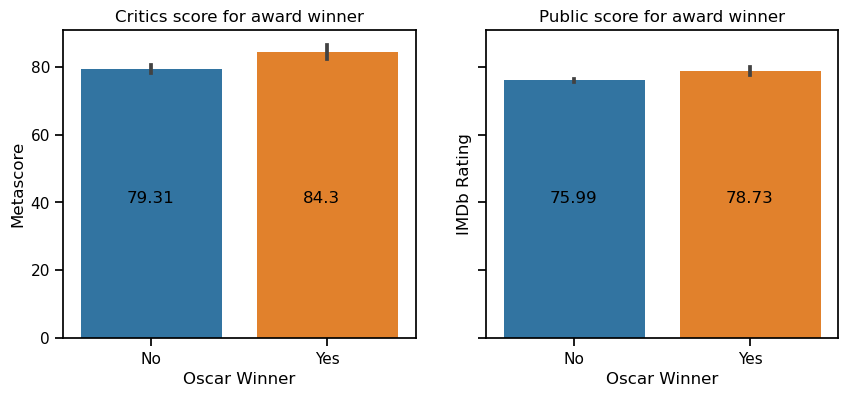

In [18]:
fig, ax = plt.subplots(1,2, figsize =(10,4), sharey=True)

sns.barplot(data=nominees,
            x="awardWinner",
            y='Metascore',
            ax=ax[0])
ax[0].set_xticklabels(['No', 'Yes'])
ax[0].set_xlabel('Oscar Winner')
notWinnerMean = nominees[nominees["awardWinner"]== 0]['Metascore'].mean()
ax[0].text(x=-0.14, y=40, s=f'{round(notWinnerMean,2)}')
winnerMean = nominees[nominees["awardWinner"]== 1]['Metascore'].mean()
ax[0].text(x=0.86, y=40, s=f'{round(winnerMean,2)}')
ax[0].set_title('Critics score for award winner')


sns.barplot(data=nominees,
            x="awardWinner",
            y='IMDb Rating',
            ax=ax[1])
ax[1].set_xticklabels(['No', 'Yes'])
ax[1].set_xlabel('Oscar Winner')
notWinnerMean = nominees[nominees["awardWinner"]== 0]['IMDb Rating'].mean()
ax[1].text(x=-0.14, y=40, s=f'{round(notWinnerMean,2)}')
winnerMean = nominees[nominees["awardWinner"]== 1]['IMDb Rating'].mean()
ax[1].text(x=0.86, y=40, s=f'{round(winnerMean,2)}')
ax[1].set_title('Public score for award winner')
plt.show()

Oscar winners tend to have a higher score than the runner ups. However, there is a clear difference between the popular opinion and the critcs opion on the nominees. There's a higher discrepancy between the two categories: winner and not winner at the critics opinion. This shows that being a Oscar Best Picture Award doesn't necessarily mean that the general public thinks it is a great movie.<br><br>
A way to check whether or not winning a Best Picture Award correlates to success is to look at the boxoffice performance of the movies

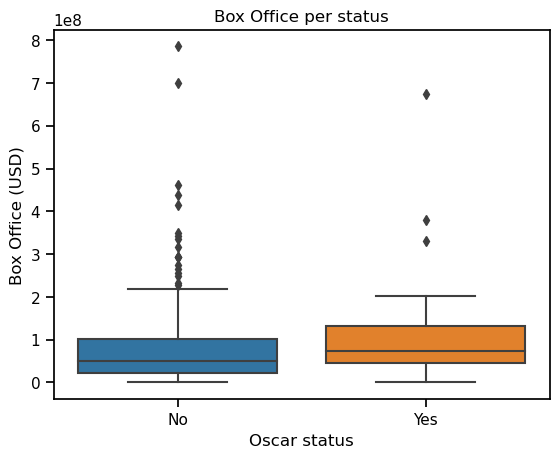

In [22]:
sns.boxplot(data=nominees,
            y='BoxOffice',
            x='awardWinner'
            )
plt.xticks([0,1], labels=['No', 'Yes'])
plt.xlabel("Oscar status")
plt.ylabel('Box Office (USD)')
plt.title('Box Office per status')
plt.show()

In [73]:
languages_dict = {}
for row in nominees.Language:
    for element in row:
        element = element.strip()
        if element in list(languages_dict.keys()):
            languages_dict[element] += 1
        else:
            languages_dict[element] = 1

languages = pd.DataFrame.from_dict(languages_dict, orient='index')
languages = languages.reset_index()
languages.columns = ['language','count']
languages_sorted = languages.sort_values(by='count', ascending=False)
languages_sorted.head(10)

,language,count
0,English,477
5,French,105
1,German,69
9,Spanish,54
7,Italian,39
2,Latin,30
10,Russian,27
17,Arabic,17
8,Japanese,17
18,Hebrew,8


In [80]:
set(languages.language)

{'Afrikaans',
 'American Sign',
 'Arabic',
 'Arapaho',
 'Armenian',
 'Bengali',
 'Berber languages',
 'British Sign',
 'Cantonese',
 'Central Khmer',
 'Chinese',
 'Czech',
 'Danish',
 'Dutch',
 'English',
 'Esperanto',
 'Finnish',
 'French',
 'Gaelic',
 'German',
 'Greek',
 'Greenlandic',
 'Guarani',
 'Hebrew',
 'Hindi',
 'Hungarian',
 'Irish Gaelic',
 'Italian',
 'Japanese',
 'Japanese Sign',
 'Korean',
 'Kurdish',
 'Latin',
 'Latvian',
 'Maltese',
 'Mandarin',
 'Maori',
 'Mixtec',
 'Nama',
 'Nepali',
 'Norwegian',
 'Nyanja',
 'Old English',
 'Pashtu',
 'Pawnee',
 'Persian',
 'Polish',
 'Polynesian',
 'Portuguese',
 'Quenya',
 'Russian',
 'Serbo-Croatian',
 'Sicilian',
 'Sindarin',
 'Sioux',
 'Somali',
 'Sotho',
 'Spanish',
 'Swahili',
 'Swedish',
 'Thai',
 'Tok Pisin',
 'Turkish',
 'Ukrainian',
 'Urdu',
 'Vietnamese',
 'Welsh',
 'Xhosa',
 'Yiddish',
 'Zulu'}

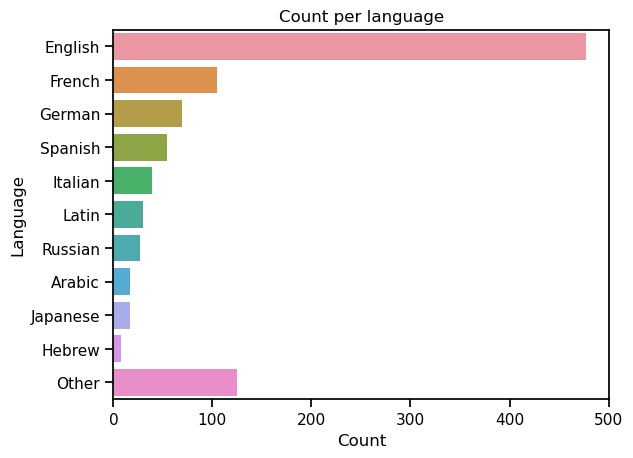

In [76]:
top10_lang = languages_sorted.head(10)
top10_lang = top10_lang.reset_index().drop('index',axis=1)
top10_lang.loc[len(top10_lang)] = ['Other', sum(languages_sorted.tail(-10)['count'])]
sns.barplot(data=top10_lang,
            y='language',
            x='count')
plt.xlabel('Count')
plt.ylabel('Language')
plt.title('Count per language')
plt.show()

In [84]:
filter = languages[languages['language'].str.endswith('Sign')]
filter

,language,count
4,American Sign,6
14,British Sign,3
38,Japanese Sign,1
